# Линейная регрессия и SGD

Спрогнозируем продажи по рекламным расходам и сравним аналитическую линейную регрессию со стохастическим градиентным спуском.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные

,TV,Radio,Newspaper,Sales
0,12.703834,18.763907,117.048519,5.186440
1,133.481328,48.496594,55.317699,18.848105
2,164.096336,8.646365,77.103107,15.834817
3,44.022970,15.983278,110.239754,10.725402
4,100.885749,14.698024,29.840959,7.111533


,count,mean,std,min,25%,50%,75%,max
TV,500.0,146.617105,87.086626,1.457201,73.653765,146.402058,224.205268,299.929601
Radio,500.0,25.019550,14.420587,0.049500,12.241616,25.222581,37.349811,49.969502
Newspaper,500.0,59.275001,35.372874,0.077076,29.283047,60.716395,89.024089,119.929071
Sales,500.0,14.420952,5.172234,2.494658,10.723214,14.031589,17.994561,27.541602


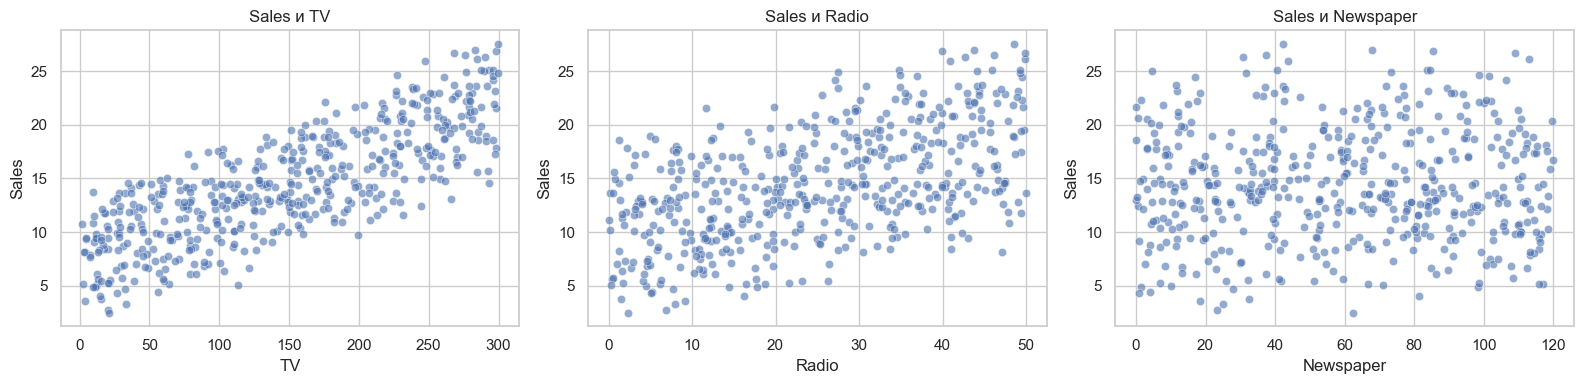

In [2]:
data = pd.read_csv("advertising.csv")
display(data.head())
display(data.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for column, axis in zip(["TV", "Radio", "Newspaper"], axes):
    sns.scatterplot(data=data, x=column, y="Sales", ax=axis, alpha=0.6)
    axis.set_title(f"Sales и {column}")
plt.tight_layout()
plt.show()

## Обучение и сравнение

In [3]:
features = data.drop(columns="Sales")
target = data["Sales"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42
)

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "SGD Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDRegressor(max_iter=5000, tol=1e-5, penalty="l2", alpha=0.001, random_state=42)),
    ]),
}

rows = []
predictions = {}
for name, model in models.items():
    model.fit(train_features, train_target)
    prediction = model.predict(test_features)
    predictions[name] = prediction
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(test_target, prediction),
        "RMSE": root_mean_squared_error(test_target, prediction),
        "R2": model.score(test_features, test_target),
    })

results = pd.DataFrame(rows).set_index("model")
results

,MAE,RMSE,R2
model,,,
Linear Regression,1.455122,1.788577,0.854799
SGD Regressor,1.453894,1.787581,0.854961


## Факт и прогноз

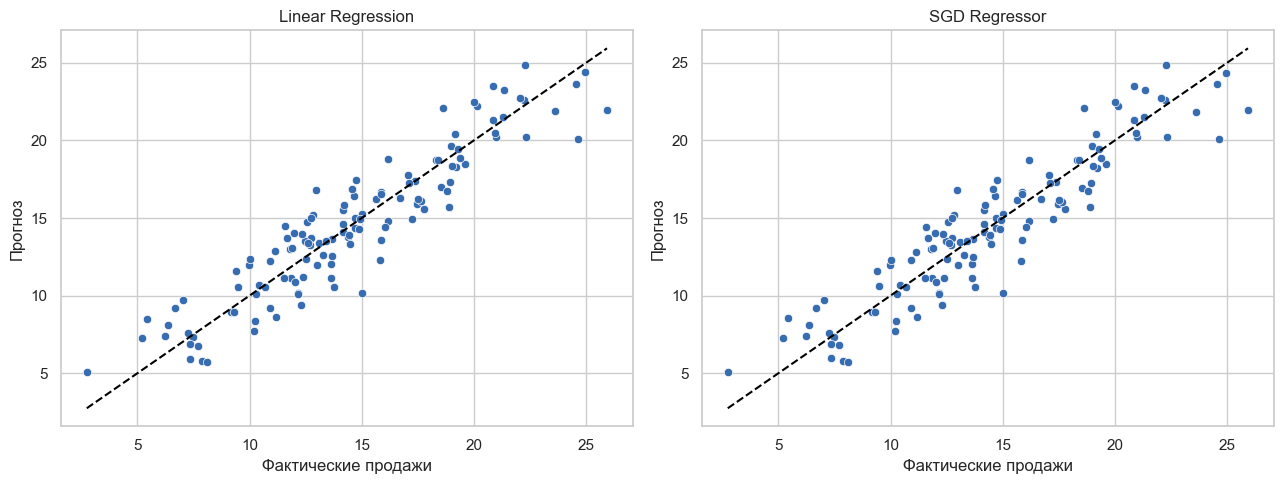

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
limits = [test_target.min(), test_target.max()]
for axis, (name, prediction) in zip(axes, predictions.items()):
    sns.scatterplot(x=test_target, y=prediction, ax=axis, color="#386cb0")
    axis.plot(limits, limits, linestyle="--", color="black")
    axis.set_title(name)
    axis.set_xlabel("Фактические продажи")
    axis.set_ylabel("Прогноз")
plt.tight_layout()
plt.show()

## Коэффициенты

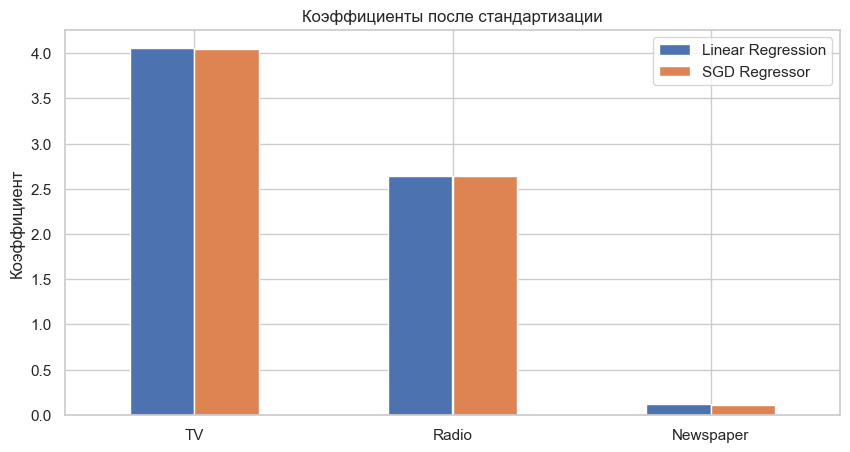

In [5]:
coefficient_frame = pd.DataFrame({
    name: model.named_steps["model"].coef_
    for name, model in models.items()
}, index=features.columns)

coefficient_frame.plot.bar(figsize=(10, 5))
plt.title("Коэффициенты после стандартизации")
plt.ylabel("Коэффициент")
plt.xticks(rotation=0)
plt.show()

## Вывод

Обе модели решают одну задачу, но SGD обновляет параметры по отдельным объектам или мини-батчам. Масштабирование признаков критично для устойчивой сходимости градиентного метода.

## Расширенный анализ оптимизации

In [6]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_score, learning_curve

### Корреляции и baseline

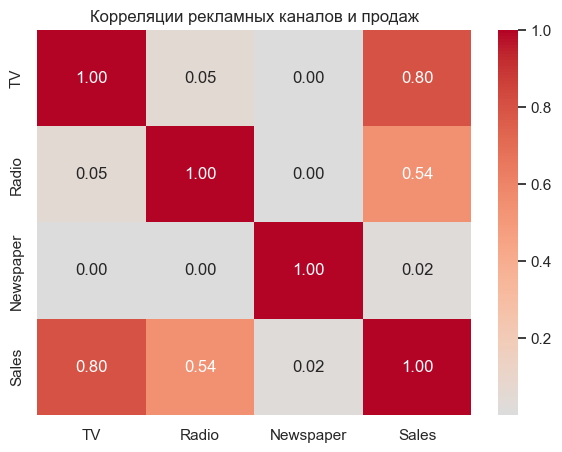

,MAE,RMSE,R2
model,,,
Mean baseline,3.744233,4.694922,-0.000486
Linear Regression,1.455122,1.788577,0.854799
SGD Regressor,1.453894,1.787581,0.854961


In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции рекламных каналов и продаж")
plt.show()

dummy = DummyRegressor(strategy="mean").fit(train_features, train_target)
dummy_prediction = dummy.predict(test_features)
baseline_row = pd.DataFrame({
    "model": ["Mean baseline"],
    "MAE": [mean_absolute_error(test_target, dummy_prediction)],
    "RMSE": [root_mean_squared_error(test_target, dummy_prediction)],
    "R2": [dummy.score(test_features, test_target)],
}).set_index("model")
pd.concat([baseline_row, results])

### Настройка SGD

,penalty,alpha,rmse
2,l2,0.000100,1.706376
1,l2,0.000032,1.706376
0,l2,0.000010,1.706376
18,elasticnet,0.000010,1.706376
19,elasticnet,0.000032,1.706376
20,elasticnet,0.000100,1.706376
9,l1,0.000010,1.706376
10,l1,0.000032,1.706376
21,elasticnet,0.000316,1.706377
11,l1,0.000100,1.706377


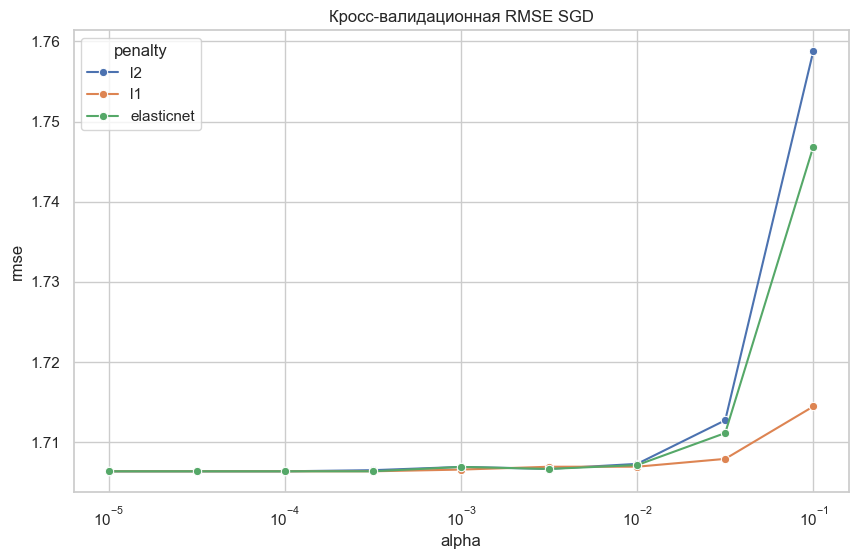

In [8]:
validation = KFold(n_splits=7, shuffle=True, random_state=42)
sgd_rows = []
for penalty in ["l2", "l1", "elasticnet"]:
    for alpha in np.logspace(-5, -1, 9):
        candidate = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SGDRegressor(
                max_iter=10000,
                tol=1e-6,
                penalty=penalty,
                alpha=alpha,
                l1_ratio=0.2,
                random_state=42,
            )),
        ])
        scores = -cross_val_score(
            candidate,
            features,
            target,
            scoring="neg_root_mean_squared_error",
            cv=validation,
        )
        sgd_rows.append({"penalty": penalty, "alpha": alpha, "rmse": scores.mean()})

sgd_search = pd.DataFrame(sgd_rows)
display(sgd_search.sort_values("rmse").head(10))

plt.figure(figsize=(10, 6))
sns.lineplot(data=sgd_search, x="alpha", y="rmse", hue="penalty", marker="o")
plt.xscale("log")
plt.title("Кросс-валидационная RMSE SGD")
plt.show()

### Сходимость при ручном partial_fit

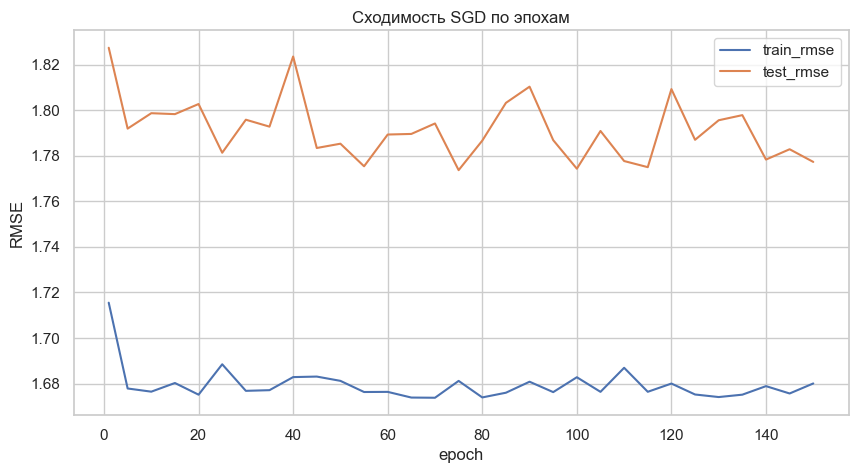

In [9]:
scaler = StandardScaler().fit(train_features)
scaled_train = scaler.transform(train_features)
scaled_test = scaler.transform(test_features)
optimizer = SGDRegressor(
    learning_rate="constant",
    eta0=0.01,
    penalty="l2",
    alpha=0.001,
    random_state=42,
)
rng = np.random.default_rng(42)
epoch_rows = []
for epoch in range(1, 151):
    order = rng.permutation(len(scaled_train))
    optimizer.partial_fit(scaled_train[order], train_target.iloc[order])
    if epoch == 1 or epoch % 5 == 0:
        epoch_rows.append({
            "epoch": epoch,
            "train_rmse": root_mean_squared_error(train_target, optimizer.predict(scaled_train)),
            "test_rmse": root_mean_squared_error(test_target, optimizer.predict(scaled_test)),
        })

epoch_results = pd.DataFrame(epoch_rows)
epoch_results.set_index("epoch")[["train_rmse", "test_rmse"]].plot(figsize=(10, 5))
plt.title("Сходимость SGD по эпохам")
plt.ylabel("RMSE")
plt.show()

### Learning curve лучшей SGD-конфигурации

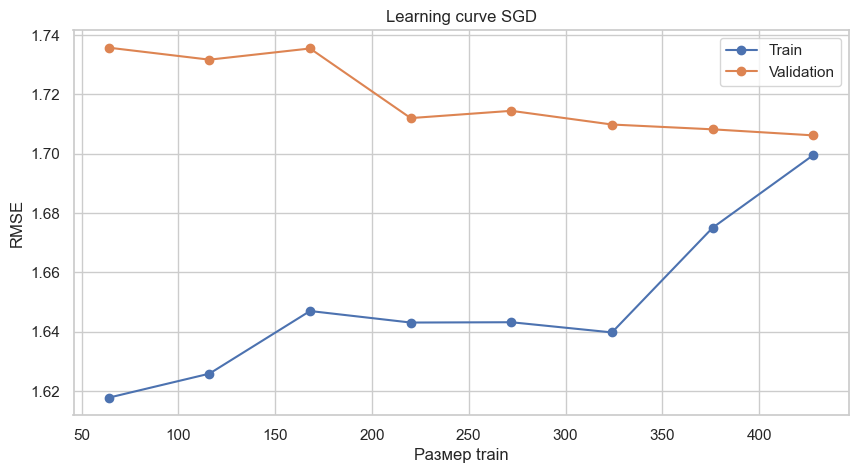

In [10]:
best_sgd_row = sgd_search.sort_values("rmse").iloc[0]
best_sgd = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(
        max_iter=10000,
        tol=1e-6,
        penalty=best_sgd_row["penalty"],
        alpha=best_sgd_row["alpha"],
        l1_ratio=0.2,
        random_state=42,
    )),
])
sizes, train_scores, validation_scores = learning_curve(
    best_sgd,
    features,
    target,
    cv=validation,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.15, 1.0, 8),
)

plt.figure(figsize=(10, 5))
plt.plot(sizes, -train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, -validation_scores.mean(axis=1), marker="o", label="Validation")
plt.title("Learning curve SGD")
plt.xlabel("Размер train")
plt.ylabel("RMSE")
plt.legend()
plt.show()

### Ошибки по моделям

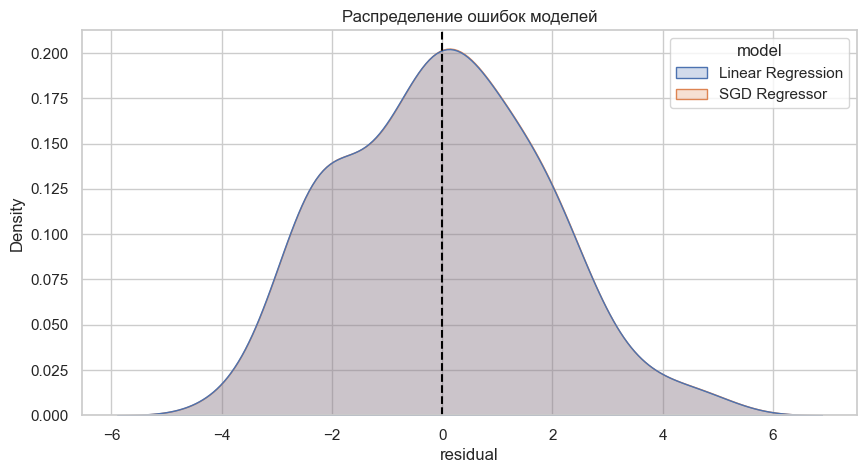

In [11]:
residual_rows = []
for name, model_prediction in predictions.items():
    for value in test_target.to_numpy() - model_prediction:
        residual_rows.append({"model": name, "residual": value})
residual_data = pd.DataFrame(residual_rows)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=residual_data, x="residual", hue="model", fill=True, common_norm=False, alpha=0.25)
plt.axvline(0, linestyle="--", color="black")
plt.title("Распределение ошибок моделей")
plt.show()

### Реакция модели на изменение рекламного бюджета

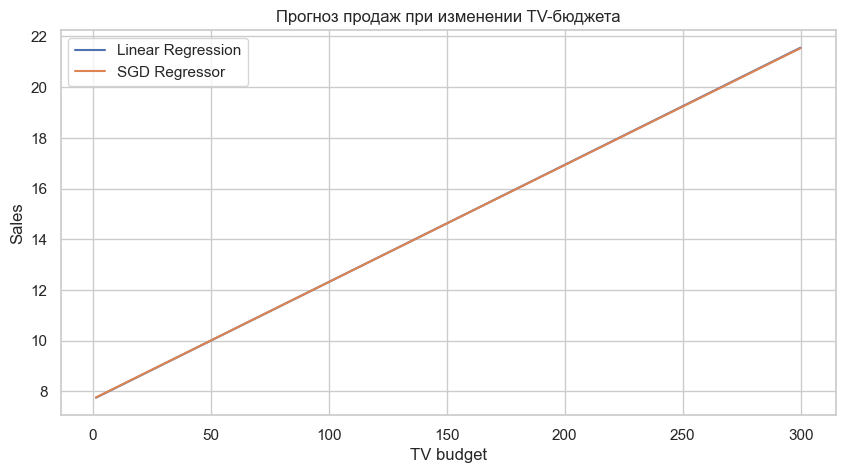

In [12]:
scenario = pd.DataFrame({
    "TV": np.linspace(data["TV"].min(), data["TV"].max(), 100),
    "Radio": data["Radio"].median(),
    "Newspaper": data["Newspaper"].median(),
})

plt.figure(figsize=(10, 5))
for name, fitted_model in models.items():
    plt.plot(scenario["TV"], fitted_model.predict(scenario), label=name)
plt.title("Прогноз продаж при изменении TV-бюджета")
plt.xlabel("TV budget")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Итог расширенного анализа

SGD требует масштабирования и чувствителен к learning rate, alpha и типу регуляризации. График по эпохам позволяет увидеть сходимость, а learning curve показывает, ограничивает ли качество объём данных или спецификация модели.